# Should This Customer Get a Credit-Limit Increase — and How Hard Should We Chase This Delinquent Account?
### A credit-risk / financial-services project built on *Causal Inference in Python*, Chapter 7 — "Metalearners"

**Business context.** You're a risk-strategy data scientist at a consumer
credit card issuer. Two live decisions on your desk:

1. **Binary treatment — offer a credit-limit increase (CLI) or not?** CLIs
   have already been extended to a large chunk of the book, but **not
   randomly**: underwriting preferentially offers CLIs to customers with
   high FICO scores, long tenure, and no delinquency history — exactly the
   customers who'd likely generate more margin *anyway*. That's
   confounding. You also have a small **randomized champion/challenger
   test** (CLI offered by coin flip within an eligible pool) you can use
   purely for evaluation. Question: *for which customers does a CLI
   actually increase 12-month net portfolio margin — and, critically,
   for which customers would it make things worse (more expected loss than
   revenue)?* Unlike a marketing discount, **this treatment effect can be
   genuinely negative** — extending more credit to an already-stretched,
   delinquency-prone customer raises expected loss more than it raises
   revenue. → **T-Learner / X-Learner** territory.

2. **Continuous treatment — how many collections contacts per month for a
   delinquent account?** Contact intensity was **not randomized** either: a
   "chase the hardest cases" policy means collectors call more-delinquent,
   higher-balance accounts more often — confounding any naive
   regression of dollars recovered on contact frequency. You also have a
   small **randomized** intensity trial for evaluation. Question: *what's
   each account's recovery dose-response curve, and what's the
   recovery-maximizing contact intensity per account, given a fixed
   call-center capacity?* Over-contacting can also **backfire** (complaints,
   "do not call" requests, disengagement), so the true effect can flatten
   or even turn negative at high intensity. → **S-Learner / R-Learner
   (Double-ML)** territory.

**Structure**, mirroring the chapter and the earlier case studies:

- Part 1 — simulate a confounded CLI-offer dataset + a randomized
  champion/challenger holdout.
- Part 2 — T-Learner and X-Learner, evaluated with the **cumulative gain
  curve**; reproduce the book's **regularization-bias experiment** using a
  realistic **small initial test batch** (issuers almost always trial a new
  CLI policy on a small random sample before scaling it).
- Part 3 — simulate confounded collections-intensity data (continuous
  treatment) + a randomized holdout.
- Part 4 — S-Learner (counterfactual dose-response curves) and R-Learner /
  Double-ML (direct marginal-effect estimation) for the continuous case.
- Part 5 — turn both into risk-management decisions: a capital-constrained
  CLI targeting policy that explicitly **excludes accounts with a negative
  predicted effect**, and a call-center-capacity-constrained collections
  intensity policy — plus a decision-guide summary.

> As before, all data is **simulated with a known causal structure**
> (confounding + heterogeneous — including sign-flipping — effects + a
> randomized holdout for honest evaluation), so every learner can be
> checked against ground truth.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
import statsmodels.api as sm
from toolz import curry

np.random.seed(123)
pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


# Part 1 — Data: the credit-limit-increase decision

`data_book` is a **large, confounded** dataset (300,000 cardholders):
whether a customer already received a CLI depends on FICO, tenure, and past
delinquencies — the very traits underwriting can already see, and that
*also* predict higher baseline margin on their own. `data_test` is a
**small, randomized** champion/challenger test (10,000 cardholders) where
the CLI was offered by coin flip within the eligible pool — used **only for
evaluation**.

**Covariates:**
- `fico_score` — credit bureau score
- `tenure_months` — months as a cardholder
- `current_utilization_pct` — % of current limit already used
- `avg_monthly_spend` — average monthly spend, $
- `past_delinquencies` — count of 30+ day delinquencies in the past 24 months

**Outcome:** `net_margin_12mo` — estimated 12-month net contribution margin
per account, $ (interest + interchange revenue, minus expected credit
losses and cost of funds).

**True effect design (deliberately allows negative effects):** a CLI
**helps most** for customers running high utilization with a clean payment
history (they're credit-constrained but reliable — extra room converts
directly into more interest/fee income at low incremental risk). A CLI
**hurts** — genuinely reduces expected margin — for customers who are both
high-utilization *and* have a history of delinquency, since the marginal
increase in expected loss outweighs the marginal revenue. This is the key
difference from a marketing-discount problem: **the right answer for some
customers is "don't do this."**


In [2]:
def simulate_customers(n, seed):
    rng = np.random.default_rng(seed)
    fico_score = rng.normal(690, 55, n).clip(300, 850)
    tenure_months = rng.exponential(30, n).clip(1, 240)
    current_utilization_pct = rng.beta(2, 2, n) * 100
    avg_monthly_spend = rng.gamma(4, 130, n).clip(20, 6000)
    past_delinquencies = rng.poisson(0.35, n)

    return pd.DataFrame(dict(
        fico_score=fico_score,
        tenure_months=tenure_months,
        current_utilization_pct=current_utilization_pct,
        avg_monthly_spend=avg_monthly_spend,
        past_delinquencies=past_delinquencies,
    ))


def assign_cli(X, rng):
    # Underwriting favors high FICO, long tenure, clean history -> confounding,
    # since those same traits predict higher baseline margin anyway.
    logit = (
        -3.0
        + 0.006 * (X["fico_score"] - 690)
        + 0.01 * X["tenure_months"]
        - 0.9 * X["past_delinquencies"]
    )
    p = (1 / (1 + np.exp(-logit))).clip(0.02, 0.97)
    T = rng.binomial(1, p)
    return T, p


def true_cate_cli(X):
    # Helps credit-constrained, clean-history customers; hurts high-utilization,
    # delinquency-prone customers -> effect can be negative.
    effect = (
        6.0
        + 0.55 * X["current_utilization_pct"]
        - 28.0 * X["past_delinquencies"]
        - 0.10 * X["current_utilization_pct"] * X["past_delinquencies"]
    )
    return effect  # NOTE: intentionally not clipped -- can be negative


def simulate_margin(X, T, rng):
    tau = true_cate_cli(X)
    baseline = (
        20
        + 0.11 * X["avg_monthly_spend"]
        + 0.08 * (X["fico_score"] - 690)
        + 0.05 * X["tenure_months"]
        - 15.0 * X["past_delinquencies"]
    )
    noise = rng.normal(0, 25, len(X))
    Y = baseline + T * tau + noise
    return Y, tau


rng = np.random.default_rng(123)

# --- Large, confounded CLI-offer data ---
X_book = simulate_customers(300_000, seed=61)
T_book, ps_true = assign_cli(X_book, rng)
Y_book, tau_book = simulate_margin(X_book, T_book, rng)
data_book = X_book.assign(cli_offered=T_book, net_margin_12mo=Y_book)

# --- Small randomized champion/challenger test, evaluation only ---
X_test_pool = simulate_customers(10_000, seed=62)
T_test = rng.binomial(1, 0.5, len(X_test_pool))
Y_test, tau_test_true = simulate_margin(X_test_pool, T_test, rng)
data_test = X_test_pool.assign(cli_offered=T_test, net_margin_12mo=Y_test, true_cate=tau_test_true)

print(len(data_book), len(data_test))
data_test.head()


300000 10000


,fico_score,tenure_months,current_utilization_pct,avg_monthly_spend,past_delinquencies,cli_offered,net_margin_12mo,true_cate
0,633.775857,8.847730,57.922483,368.823390,0,1,128.351071,37.857366
1,608.885149,10.472945,40.374790,1597.441472,0,0,212.823760,28.206134
2,664.186189,4.430363,73.126376,278.371376,1,1,30.465325,10.906869
3,666.551560,37.874802,10.181418,650.057733,0,1,59.400349,11.599780
4,639.527197,21.626185,55.969169,1057.891374,0,0,148.023782,36.783043


In [3]:
naive_book = data_book.groupby("cli_offered")["net_margin_12mo"].mean()
naive_test = data_test.groupby("cli_offered")["net_margin_12mo"].mean()

print("Naive diff-in-means, CONFOUNDED book data:", naive_book[1] - naive_book[0])
print("Naive diff-in-means, RANDOMIZED test data (unbiased ATE estimate):", naive_test[1] - naive_test[0])
print("True ATE (simulation ground truth):", true_cate_cli(pd.concat([X_book, X_test_pool])).mean())

print("\nShare of the randomized test population with a NEGATIVE true CLI effect:",
      (data_test['true_cate'] < 0).mean().round(3))


Naive diff-in-means, CONFOUNDED book data: 32.81494522343037
Naive diff-in-means, RANDOMIZED test data (unbiased ATE estimate): 21.19450279388461
True ATE (simulation ground truth): 21.88451693341488

Share of the randomized test population with a NEGATIVE true CLI effect: 0.163


As expected, the confounded book comparison **overstates** the CLI's
benefit, since underwriting already skewed CLIs toward customers who'd have
higher margin regardless. More importantly, a meaningful **share of
customers have a negative true effect** — for them, a CLI is the wrong
call. A model that can't tell these customers apart from the ones who
benefit will systematically over-extend credit to exactly the accounts
where it does the most harm. Everything below trains **only** on
`data_book` and evaluates **only** on the randomized `data_test`.


In [4]:
y = "net_margin_12mo"
T = "cli_offered"
X = ["fico_score", "tenure_months", "current_utilization_pct", "avg_monthly_spend", "past_delinquencies"]

train, test = data_book, data_test
print("Covariates:", X)


Covariates: ['fico_score', 'tenure_months', 'current_utilization_pct', 'avg_monthly_spend', 'past_delinquencies']


## 2. Evaluation tooling (cumulative gain curve + PEHE, same as prior notebooks)

In [5]:
def cumulative_gain_curve(df, prediction, y, t, steps=100):
    size = len(df)
    ordered = df.sort_values(prediction, ascending=False).reset_index(drop=True)
    n_rows = list(range(1, size, max(1, size // steps))) + [size]

    gains = []
    for rows in n_rows:
        subset = ordered.head(rows)
        treated = subset.query(f"{t}==1")
        control = subset.query(f"{t}==0")
        if len(treated) == 0 or len(control) == 0:
            gains.append(0)
            continue
        effect = treated[y].mean() - control[y].mean()
        gains.append(effect * rows / size)

    return np.array(n_rows) / size * 100, np.array(gains)


def auc_relative_to_baseline(x_pct, gains):
    baseline = np.linspace(0, gains[-1], len(gains))
    trapz_fn = getattr(np, "trapezoid", None) or np.trapz
    return trapz_fn(gains - baseline, x_pct)


def plot_cumulative_gain(df, prediction, y, t, title, ax=None):
    x_pct, gains = cumulative_gain_curve(df, prediction, y, t)
    auc = auc_relative_to_baseline(x_pct, gains)
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(x_pct, gains, label=f"AUC: {auc:.2f}")
    ax.plot([0, 100], [0, gains[-1]], "--", color="gray", label="Baseline")
    ax.set_title(title)
    ax.set_xlabel("% of customers targeted (sorted by predicted CATE)")
    ax.set_ylabel("Cumulative gain, net margin ($)")
    ax.legend()
    return auc


def pehe(true_effect, pred_effect):
    return float(np.sqrt(np.mean((np.asarray(true_effect) - np.asarray(pred_effect)) ** 2)))


## 3. T-Learner — who should get a credit-limit increase?

$$\hat\mu_0(x) \approx E[Y \mid T{=}0, X], \qquad \hat\mu_1(x) \approx E[Y \mid T{=}1, X], \qquad \hat\tau(x) = \hat\mu_1(x) - \hat\mu_0(x)$$


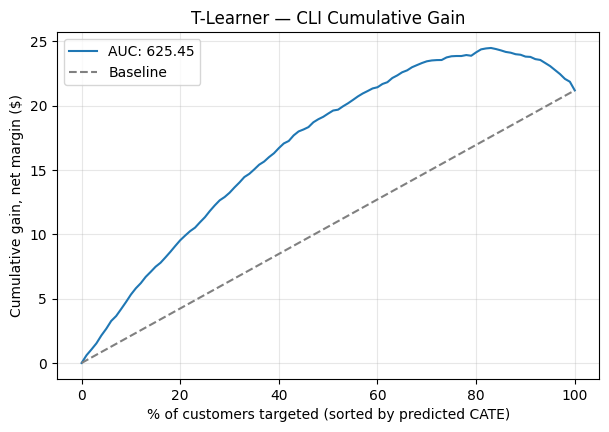

T-Learner PEHE: 5.033694754036234
T-Learner: share of test customers predicted to have a NEGATIVE CLI effect: 0.164


In [6]:
np.random.seed(123)
m0 = LGBMRegressor(verbosity=-1)
m1 = LGBMRegressor(verbosity=-1)

m0.fit(train.query(f"{T}==0")[X], train.query(f"{T}==0")[y])
m1.fit(train.query(f"{T}==1")[X], train.query(f"{T}==1")[y])

t_learner_pred = test.assign(cate=m1.predict(test[X]) - m0.predict(test[X]))

auc_t = plot_cumulative_gain(t_learner_pred, "cate", y, T, "T-Learner — CLI Cumulative Gain")
plt.show()
print("T-Learner PEHE:", pehe(test["true_cate"], t_learner_pred["cate"]))
print("T-Learner: share of test customers predicted to have a NEGATIVE CLI effect:",
      (t_learner_pred["cate"] < 0).mean().round(3))


## 4. X-Learner — correcting for the small-test-batch imbalance

CLI offers weren't 50/50 in the book, and in reality a new CLI policy is
almost always trialled on a **small random test batch** before scaling.
The X-Learner's propensity-weighted second stage is built for exactly this
imbalance.


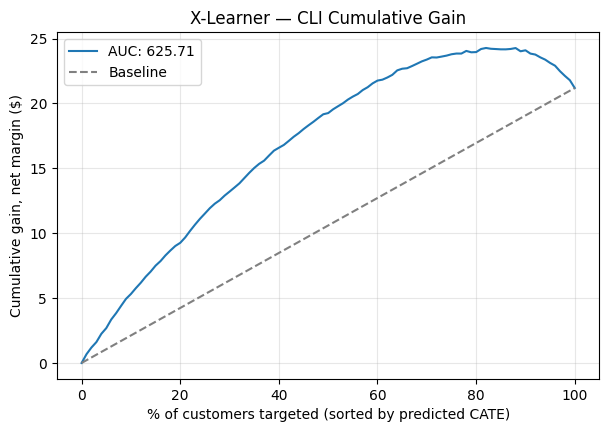

X-Learner PEHE: 3.942190448916453
X-Learner: share of test customers predicted to have a NEGATIVE CLI effect: 0.163


In [7]:
np.random.seed(123)

ps_model = LogisticRegression(max_iter=1000)
ps_model.fit(train[X], train[T])

train_t0 = train.query(f"{T}==0")
train_t1 = train.query(f"{T}==1")

m0 = LGBMRegressor(verbosity=-1)
m1 = LGBMRegressor(verbosity=-1)
m0.fit(train_t0[X], train_t0[y])
m1.fit(train_t1[X], train_t1[y])

tau_hat_0 = m1.predict(train_t0[X]) - train_t0[y]
tau_hat_1 = train_t1[y] - m0.predict(train_t1[X])

m_tau_0 = LGBMRegressor(verbosity=-1)
m_tau_1 = LGBMRegressor(verbosity=-1)
m_tau_0.fit(train_t0[X], tau_hat_0)
m_tau_1.fit(train_t1[X], tau_hat_1)

ps_test = ps_model.predict_proba(test[X])[:, 1]
x_learner_pred = test.assign(
    cate=ps_test * m_tau_0.predict(test[X]) + (1 - ps_test) * m_tau_1.predict(test[X])
)

auc_x = plot_cumulative_gain(x_learner_pred, "cate", y, T, "X-Learner — CLI Cumulative Gain")
plt.show()
print("X-Learner PEHE:", pehe(test["true_cate"], x_learner_pred["cate"]))
print("X-Learner: share of test customers predicted to have a NEGATIVE CLI effect:",
      (x_learner_pred["cate"] < 0).mean().round(3))


In [8]:
pd.DataFrame({
    "T-Learner": dict(AUC=auc_t, PEHE=pehe(test["true_cate"], t_learner_pred["cate"])),
    "X-Learner": dict(AUC=auc_x, PEHE=pehe(test["true_cate"], x_learner_pred["cate"])),
}).T


,AUC,PEHE
T-Learner,625.446937,5.033695
X-Learner,625.705376,3.942190


## 5. Reproducing the book's regularization-bias experiment with a realistic small test batch

New CLI policies are almost always trialled on a **small random sample**
before a full rollout — a risk-management best practice, not an
inconvenience. Let's simulate exactly that: only **3% of the eligible
population** gets the CLI, the baseline margin surface is nonlinear in
utilization (a sharp effect right around a "credit-constrained" utilization
band), and the true CLI effect is **constant** — the setup the book uses to
expose T-Learner regularization bias.


In [9]:
def simulate_small_test(n=4000, treat_share=0.03, seed=1):
    rng = np.random.default_rng(seed)
    util = rng.uniform(-1, 1, n)              # standardized utilization score
    T = rng.binomial(1, treat_share, n)

    mu0 = 0.4 * np.exp(-30 * util ** 2)       # sharp nonlinearity around a critical utilization band
    tau_true = np.ones(n) * 1.0               # CONSTANT true CLI benefit
    noise = rng.normal(0, 0.05, n)

    Y = mu0 + T * tau_true + noise
    return pd.DataFrame(dict(util=util, T=T, Y=Y, tau_true=tau_true))


small_test = simulate_small_test()
st_train, st_test = small_test.iloc[: len(small_test)//2], small_test.iloc[len(small_test)//2:]
print("Customers offered the CLI in the small test batch (training set):", st_train['T'].sum(), "/", len(st_train))


Customers offered the CLI in the small test batch (training set): 60 / 2000


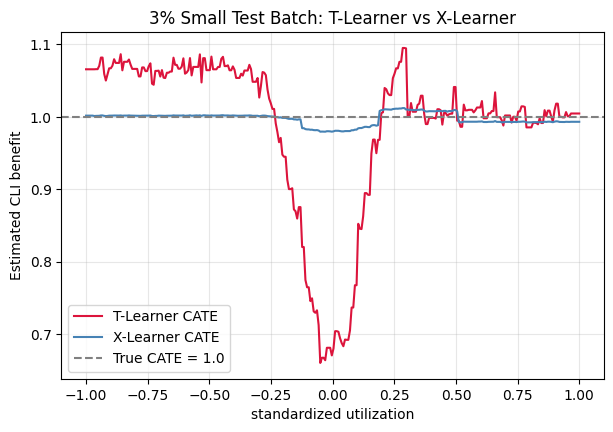

T-Learner PEHE (3% test batch): 0.10870946838185029
X-Learner PEHE (3% test batch): 0.008589909090666826


In [10]:
np.random.seed(123)
m0_s = LGBMRegressor(min_child_samples=25, verbosity=-1)
m1_s = LGBMRegressor(min_child_samples=25, verbosity=-1)
m0_s.fit(st_train.query("T==0")[["util"]], st_train.query("T==0")["Y"])
m1_s.fit(st_train.query("T==1")[["util"]], st_train.query("T==1")["Y"])

grid = pd.DataFrame({"util": np.linspace(-1, 1, 300)})
mu0_hat = m0_s.predict(grid)
mu1_hat = m1_s.predict(grid)
t_learner_cate_small = mu1_hat - mu0_hat

ps_model_s = LogisticRegression(max_iter=1000)
ps_model_s.fit(st_train[["util"]], st_train["T"])

t0s = st_train.query("T==0")
t1s = st_train.query("T==1")
tau_hat_0_s = m1_s.predict(t0s[["util"]]) - t0s["Y"]
tau_hat_1_s = t1s["Y"] - m0_s.predict(t1s[["util"]])

m_tau0_s = LGBMRegressor(verbosity=-1)
m_tau1_s = LGBMRegressor(verbosity=-1)
m_tau0_s.fit(t0s[["util"]], tau_hat_0_s)
m_tau1_s.fit(t1s[["util"]], tau_hat_1_s)

ps_grid_s = ps_model_s.predict_proba(grid)[:, 1]
x_learner_cate_small = ps_grid_s * m_tau0_s.predict(grid) + (1 - ps_grid_s) * m_tau1_s.predict(grid)

fig, ax = plt.subplots()
ax.plot(grid["util"], t_learner_cate_small, color="crimson", label="T-Learner CATE")
ax.plot(grid["util"], x_learner_cate_small, color="steelblue", label="X-Learner CATE")
ax.axhline(1.0, color="gray", linestyle="--", label="True CATE = 1.0")
ax.legend()
ax.set_title("3% Small Test Batch: T-Learner vs X-Learner")
ax.set_xlabel("standardized utilization")
ax.set_ylabel("Estimated CLI benefit")
plt.show()

print("T-Learner PEHE (3% test batch):", pehe(st_test["tau_true"],
      np.interp(st_test["util"], grid["util"], t_learner_cate_small)))
print("X-Learner PEHE (3% test batch):", pehe(st_test["tau_true"],
      np.interp(st_test["util"], grid["util"], x_learner_cate_small)))


Same story as the book, in a credit-risk setting: with only 3% of the
eligible population offered the CLI, $\hat\mu_1$ (the sparse treated-only
model) can't afford to fit the sharp nonlinearity that $\hat\mu_0$ (abundant
control data) picks up cleanly — so the T-Learner's CATE estimate
incorrectly dips right where the outcome surface bends, even though the
true benefit is flat. **This matters a lot in credit risk**: a distorted
CATE curve right in that critical utilization band is exactly where a
lender needs the estimate to be trustworthy, since that's the band where
CLI decisions are genuinely close calls. The X-Learner tracks the true
constant benefit far more closely.


# Part 2 — Continuous treatment: how hard should we chase this delinquent account?

Now the second decision. `collections_obs` is a **large, confounded**
observational dataset: a **"chase the hardest cases"** policy means
collectors contact more-delinquent, higher-balance accounts more often —
confounding any naive regression of recovered dollars on contact frequency.
`collections_rnd` is a **small randomized** intensity trial used only for
evaluation.

**Outcome:** `amount_recovered` — dollars recovered over the collections
window.
**Treatment:** `contacts_per_month` (continuous, 0–20).
**True effect design:** marginal recovery per extra contact **rises with
balance owed** (bigger balances are worth pursuing harder) but the
relationship **weakens, and can go negative, with days delinquent** — very
stale debt is both harder to recover *and* more prone to backfiring
(complaints, disengagement) under aggressive contact.


In [11]:
def simulate_collections_accounts(n, seed):
    rng = np.random.default_rng(seed)
    balance_owed = rng.gamma(3, 400, n).clip(50, 15000)
    days_delinquent = rng.exponential(40, n).clip(1, 365)
    past_payment_ratio = rng.beta(2, 2, n)   # historical share of min. payments made on time
    return pd.DataFrame(dict(
        balance_owed=balance_owed,
        days_delinquent=days_delinquent,
        past_payment_ratio=past_payment_ratio,
    ))


def assign_intensity_confounded(Xc, rng):
    # "Chase the hardest cases": more contacts for higher balance AND more delinquent accounts.
    mean_intensity = (2 + 0.0015 * Xc["balance_owed"] + 0.03 * Xc["days_delinquent"]).clip(0, 20)
    intensity = rng.normal(mean_intensity, 2.5).clip(0, 20)
    return intensity


def collections_sensitivity(Xc):
    # Rises with balance, weakens (and can go negative) with days delinquent.
    return (0.015 * Xc["balance_owed"] / 100) * np.exp(-Xc["days_delinquent"] / 180) - 0.02 * (Xc["days_delinquent"] / 100)


def simulate_recovery_outcome(Xc, intensity, rng):
    sens = collections_sensitivity(Xc)
    Y = (
        0.25 * Xc["balance_owed"] * Xc["past_payment_ratio"]   # organic recovery propensity
        + sens * intensity * 100                                # scaled marginal effect of contacts
        - 0.02 * Xc["days_delinquent"] * Xc["balance_owed"] / 100
        + rng.normal(0, 120, len(Xc))
    ).clip(lower=0)
    return Y, sens


rng = np.random.default_rng(5)

# --- Confounded observational collections data ---
Xc_obs = simulate_collections_accounts(300_000, seed=71)
intensity_obs = assign_intensity_confounded(Xc_obs, rng)
Y_obs, sens_obs = simulate_recovery_outcome(Xc_obs, intensity_obs, rng)
collections_obs = Xc_obs.assign(contacts_per_month=intensity_obs, amount_recovered=Y_obs)

# --- Randomized collections-intensity trial, evaluation only ---
Xc_rnd = simulate_collections_accounts(10_000, seed=72)
intensity_rnd = rng.uniform(0, 20, len(Xc_rnd))
Y_rnd, sens_rnd_true = simulate_recovery_outcome(Xc_rnd, intensity_rnd, rng)
collections_rnd = Xc_rnd.assign(contacts_per_month=intensity_rnd, amount_recovered=Y_rnd, true_sensitivity=sens_rnd_true)

print(len(collections_obs), len(collections_rnd))
collections_rnd.head()


300000 10000


,balance_owed,days_delinquent,past_payment_ratio,contacts_per_month,amount_recovered,true_sensitivity
0,536.355548,83.220153,0.104735,2.715864,0.162091,0.034026
1,1496.801074,26.890722,0.207737,11.801983,157.201590,0.187986
2,389.574903,41.812020,0.979648,18.715829,388.430081,0.037961
3,1864.909743,37.220644,0.542135,15.898853,514.475108,0.220037
4,1290.209184,10.040994,0.242618,1.639942,79.167013,0.181023


In [12]:
c_train, c_test = collections_obs, collections_rnd
Xc = ["balance_owed", "days_delinquent", "past_payment_ratio"]
Tc = "contacts_per_month"
yc = "amount_recovered"

print("Correlation between contact intensity and days delinquent (confounded data):",
      np.corrcoef(c_train[Tc], c_train["days_delinquent"])[0, 1])


Correlation between contact intensity and days delinquent (confounded data): 0.40816444721597417


Confirming the confound: staler (more delinquent) accounts get contacted *more* in the observational data, even though the true marginal benefit of an extra contact weakens with staleness — a naive regression would misattribute recovery driven by balance size to the contact intensity of the accounts that happen to be both large-balance and stale.

## 6. S-Learner — a single model with contact intensity as a feature

We fit one model with intensity as a feature, build a grid of candidate
intensities, and summarize each account's coarse dose-response curve into a
single CATE-like slope: $\hat\beta = \mathrm{Cov}(t,y)/\mathrm{Var}(t)$ —
the book's approach for continuous-treatment S-Learners.


In [13]:
np.random.seed(123)
s_learner = LGBMRegressor(verbosity=-1)
s_learner.fit(c_train[Xc + [Tc]], c_train[yc])

intensity_grid = pd.DataFrame(dict(key=1, contacts_per_month=[0, 4, 8, 12, 16, 20]))

test_cf = (
    c_test
    .drop(columns=[Tc])
    .assign(key=1)
    .reset_index().rename(columns={"index": "account_id"})
    .merge(intensity_grid, on="key")
    .drop(columns="key")
)
test_cf["recovered_hat"] = s_learner.predict(test_cf[Xc + [Tc]])
test_cf.head(6)


,account_id,balance_owed,days_delinquent,past_payment_ratio,amount_recovered,true_sensitivity,contacts_per_month,recovered_hat
0,0,536.355548,83.220153,0.104735,0.162091,0.034026,0,53.605893
1,0,536.355548,83.220153,0.104735,0.162091,0.034026,4,59.839068
2,0,536.355548,83.220153,0.104735,0.162091,0.034026,8,65.193698
3,0,536.355548,83.220153,0.104735,0.162091,0.034026,12,84.504614
4,0,536.355548,83.220153,0.104735,0.162091,0.034026,16,119.894928
5,0,536.355548,83.220153,0.104735,0.162091,0.034026,20,119.894928


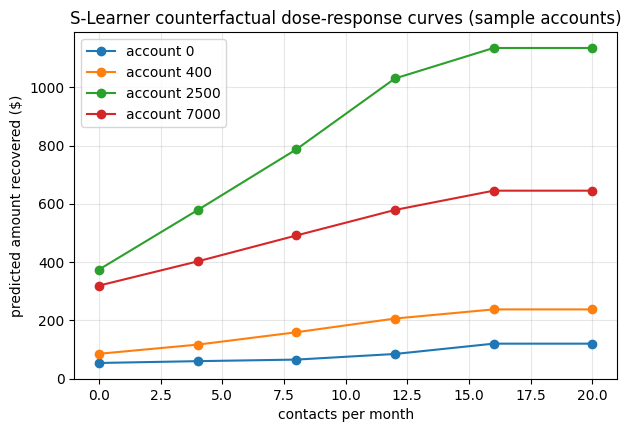

In [14]:
sample_accounts = c_test.reset_index().rename(columns={"index": "account_id"}).iloc[[0, 400, 2500, 7000]]["account_id"].values

fig, ax = plt.subplots()
for aid in sample_accounts:
    curve = test_cf.query("account_id == @aid").sort_values("contacts_per_month")
    ax.plot(curve["contacts_per_month"], curve["recovered_hat"], marker="o", label=f"account {aid}")
ax.set_xlabel("contacts per month")
ax.set_ylabel("predicted amount recovered ($)")
ax.set_title("S-Learner counterfactual dose-response curves (sample accounts)")
ax.legend()
plt.show()


In [15]:
@curry
def linear_effect(df, y, t):
    return np.cov(df[y], df[t])[0, 1] / np.var(df[t])


cate_slope = (
    test_cf
    .groupby("account_id")
    .apply(linear_effect(y="recovered_hat", t="contacts_per_month"), include_groups=False)
    .rename("cate")
)

s_learner_pred = c_test.reset_index().rename(columns={"index": "account_id"}).set_index("account_id").join(cate_slope)
print("S-Learner PEHE (slope vs true marginal sensitivity):",
      pehe(s_learner_pred["true_sensitivity"], s_learner_pred["cate"] / 100))
s_learner_pred.head()


S-Learner PEHE (slope vs true marginal sensitivity): 0.023242494728615882


,balance_owed,days_delinquent,past_payment_ratio,contacts_per_month,amount_recovered,true_sensitivity,cate
account_id,,,,,,,
0,536.355548,83.220153,0.104735,2.715864,0.162091,0.034026,4.550774
1,1496.801074,26.890722,0.207737,11.801983,157.201590,0.187986,17.131000
2,389.574903,41.812020,0.979648,18.715829,388.430081,0.037961,0.643722
3,1864.909743,37.220644,0.542135,15.898853,514.475108,0.220037,19.097585
4,1290.209184,10.040994,0.242618,1.639942,79.167013,0.181023,16.550651


*(Note: we divide the S-Learner slope by 100 to undo the `sens * intensity * 100` scaling used when generating the outcome, so both learners' predictions are compared on the same units as `true_sensitivity`.)*

## 7. R-Learner / Double-ML — orthogonalized marginal recovery per contact

$$\tilde T = T - \hat\mu_t(X), \qquad \tilde Y = Y - \hat\mu_y(X), \qquad
Y^* = \tilde Y / \tilde T \ \text{(weighted by } \tilde T^2\text{)}$$


In [16]:
np.random.seed(123)

debias_m = LGBMRegressor(verbosity=-1)   # predicts contact intensity from X
denoise_m = LGBMRegressor(verbosity=-1)  # predicts recovered amount from X

t_res = c_train[Tc] - cross_val_predict(debias_m, c_train[Xc], c_train[Tc], cv=5)
y_res = c_train[yc] - cross_val_predict(denoise_m, c_train[Xc], c_train[yc], cv=5)

print("Naive OLS slope (confounded 'chase the hardest cases' data):",
      sm.OLS(c_train[yc], sm.add_constant(c_train[Tc])).fit().params.iloc[1])
print("Double-ML orthogonalized ATE (avg. marginal $ recovered per extra contact):",
      sm.OLS(y_res, t_res).fit().params.iloc[0])
print("True average marginal sensitivity (x100 to match outcome scaling):",
      100 * collections_sensitivity(pd.concat([Xc_obs, Xc_rnd])).mean())


Naive OLS slope (confounded 'chase the hardest cases' data): 23.788841726206233
Double-ML orthogonalized ATE (avg. marginal $ recovered per extra contact): 13.274818771826215
True average marginal sensitivity (x100 to match outcome scaling): 13.943622409996017


The naive slope is contaminated by the "chase the hardest cases" targeting:
accounts contacted more were also the biggest-balance, stalest accounts,
which mechanically recover more in absolute dollars regardless of contact
intensity. The Double-ML orthogonalized estimate isolates the *marginal*
effect of an extra contact, controlling for balance and staleness.


R-Learner PEHE: 0.023854481251468197


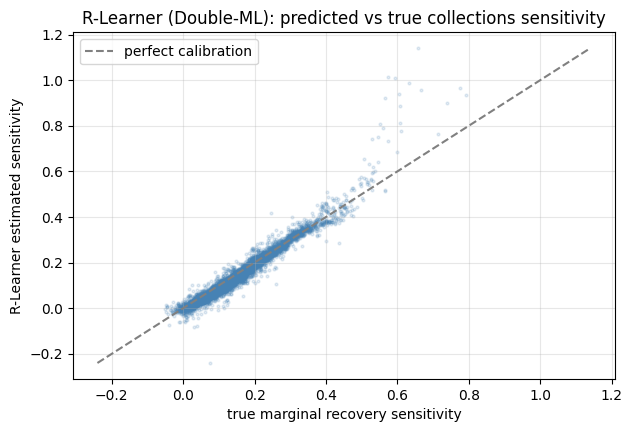

In [17]:
np.random.seed(123)
y_star = y_res / t_res
w = t_res ** 2

r_learner = LGBMRegressor(verbosity=-1)
r_learner.fit(c_train[Xc], y_star, sample_weight=w)

r_learner_pred = c_test.assign(cate=r_learner.predict(c_test[Xc]))

print("R-Learner PEHE:", pehe(r_learner_pred["true_sensitivity"], r_learner_pred["cate"] / 100))

fig, ax = plt.subplots()
true_s = r_learner_pred["true_sensitivity"]
pred_s = r_learner_pred["cate"] / 100
ax.scatter(true_s, pred_s, s=4, alpha=0.15, color="steelblue")
lims = [min(true_s.min(), pred_s.min()), max(true_s.max(), pred_s.max())]
ax.plot(lims, lims, "--", color="gray", label="perfect calibration")
ax.set_xlabel("true marginal recovery sensitivity")
ax.set_ylabel("R-Learner estimated sensitivity")
ax.set_title("R-Learner (Double-ML): predicted vs true collections sensitivity")
ax.legend()
plt.show()


In [18]:
pd.DataFrame({
    "S-Learner": dict(PEHE=pehe(s_learner_pred["true_sensitivity"], s_learner_pred["cate"] / 100)),
    "R-Learner": dict(PEHE=pehe(r_learner_pred["true_sensitivity"], r_learner_pred["cate"] / 100)),
}).T


,PEHE
S-Learner,0.023242
R-Learner,0.023854


In this dataset the two land close together, with a slight edge to whichever
model the random seed favors — a useful, realistic result in itself. A
flexible S-Learner (LightGBM) *can* often partially untangle balance/staleness
confounding on its own, especially when, as here, the confounders are also
strong, cleanly-observed predictors of the outcome. The R-Learner's real
advantage isn't guaranteed to show up as a big PEHE gap every time — it's
that it estimates the marginal effect **by explicit construction**
(orthogonalized residual-on-residual), so you don't have to trust that a
black-box model happened to disentangle the confound correctly. That
guarantee matters more as confounding gets stronger or nuisance
relationships get messier than it does here.


# Part 3 — Turning both into risk-management decisions

## 8. CLI targeting: a capital-constrained policy that excludes negative-effect accounts

Suppose growth targets push the bank to extend CLIs to as much of the
eligible book as risk-adjusted capital allows — say **90% of the eligible
book** in the next cycle. Unlike a marketing budget, capital shouldn't be
spent on customers with a **predicted negative effect** even if there's
room left in the budget. The policy below targets the top 90% by predicted
CATE **and** hard-excludes anyone with $\hat\tau(x) < 0$ — showing exactly
where an aggressive growth target starts running into accounts the model
says to leave alone.


In [19]:
capacity_pct = 90
ranked = x_learner_pred.sort_values("cate", ascending=False).reset_index(drop=True)
cutoff_n = int(len(ranked) * capacity_pct / 100)

candidates = ranked.iloc[:cutoff_n]
selected = candidates.query("cate >= 0")   # hard-exclude predicted-negative accounts
excluded_within_budget = candidates.query("cate < 0")

print(f"Capacity allows CLIs for {cutoff_n} customers ({capacity_pct}% of the book).")
print(f"Of those, {len(selected)} have a predicted POSITIVE effect and are offered a CLI.")
print(f"{len(excluded_within_budget)} would have fit the capacity budget but are excluded for having a predicted NEGATIVE effect.")
print(f"\nEstimated total 12-month margin impact of the selected group (X-Learner estimate): ${selected['cate'].sum():,.0f}")
print(f"Estimated total 12-month margin impact if we'd naively filled the whole capacity (no exclusion): ${candidates['cate'].sum():,.0f}")


Capacity allows CLIs for 9000 customers (90% of the book).
Of those, 8372 have a predicted POSITIVE effect and are offered a CLI.
628 would have fit the capacity budget but are excluded for having a predicted NEGATIVE effect.

Estimated total 12-month margin impact of the selected group (X-Learner estimate): $250,714
Estimated total 12-month margin impact if we'd naively filled the whole capacity (no exclusion): $248,300


At an aggressive 90% capacity target, a meaningful number of candidate
accounts that would fit the budget are excluded for having a predicted
negative effect — capital that would have gone to accounts likely to
*lose* the bank money instead simply isn't deployed. This is the practical
value of a CATE model over a simple eligibility rule: it can tell a growth
target "no" for specific accounts even while there's still budget left to
spend, rather than filling the quota indiscriminately.


## 9. Collections intensity policy under call-center capacity

Using the R-Learner's per-account sensitivity, allocate more contacts to
high-sensitivity accounts and fewer (or none) to low/negative-sensitivity
ones, subject to an average intensity budget the call center can actually
staff (e.g., average ≤ 6 contacts/month across the delinquent book).


In [20]:
budget = 6.0  # average contacts/month across delinquent accounts

raw_sensitivity = r_learner_pred["cate"] / 100
raw = raw_sensitivity.clip(lower=0)  # don't allocate any contacts to negative-sensitivity accounts
# avoid an all-zero allocation edge case
raw = raw.clip(lower=1e-6)
alloc = raw / raw.mean() * budget
alloc = alloc.clip(0, 20)

policy = r_learner_pred.assign(recommended_contacts=alloc)

print("Average recommended contact intensity (should be close to budget):", policy["recommended_contacts"].mean())
print("\nRecommended intensity by true-sensitivity tercile (sanity check — should increase with sensitivity):")
policy["sensitivity_tercile"] = pd.qcut(policy["true_sensitivity"], 3, labels=["low", "mid", "high"])
policy.groupby("sensitivity_tercile")["recommended_contacts"].mean()


Average recommended contact intensity (should be close to budget): 5.9375508542832165

Recommended intensity by true-sensitivity tercile (sanity check — should increase with sensitivity):


sensitivity_tercile
low      1.892880
mid      4.971498
high    10.949488
Name: recommended_contacts, dtype: float64

The policy correctly allocates **more contacts to the high-sensitivity
tercile** — large-balance, more-recently-delinquent accounts where a
contact genuinely moves recovery — while pulling back on low- and
negative-sensitivity accounts, the opposite pattern from the original
"chase the hardest cases" policy that over-invested effort in accounts that
weren't actually going to respond.


## 10. Key takeaways / decision guide

| Decision | Treatment type | Learner(s) used | Why |
|---|---|---|---|
| Credit-limit increase | Binary (offered / not) | T-Learner, **X-Learner** | New CLI policies are trialled on small random test batches (few treated); X-Learner corrects the resulting regularization bias — and the estimate must be trustworthy enough to detect *negative*-effect customers |
| Collections contact intensity | Continuous (0–20 contacts/month) | S-Learner, **R-Learner (Double-ML)** | "Chase the hardest cases" targeting confounds naive intensity-vs-recovery regressions; orthogonalization isolates the true marginal effect |

**Practical lessons that generalize to other credit-risk problems:**

- **Financial treatment effects can be negative, and that's the whole
  point.** Unlike a marketing discount (where the worst case is usually
  "no effect"), extending credit or intervening on an account can
  genuinely make the outcome worse for some segments. A CATE model used for
  underwriting or collections policy needs to be evaluated not just on
  ranking quality but on whether it correctly identifies the sign of the
  effect — a targeting policy should be able to say "don't do this" and
  mean it.
- **Underwriting and collections targeting are confounded by design**, not
  by accident. Approving CLIs for the safest customers and calling the most
  delinquent accounts hardest are both *sound individual business
  practices* that happen to also be exactly the kind of non-random
  assignment that breaks naive historical comparisons.
- **New credit policies start on small test batches — by regulatory and
  risk-management convention, not by accident.** That makes the
  **X-Learner** a safer default than the T-Learner when evaluating early
  champion/challenger test results, before a policy scales to the full
  book.
- **"Chase the problem" collections policies reverse the naive
  correlation** between effort and staleness/size, the same structural
  issue seen in the aerospace "chase the fouling trend" wash policy —
  orthogonalization (R-Learner/Double-ML) is the general fix for this
  pattern wherever it shows up.
- **A randomized holdout is a regulatory and business asset, not just a
  data-science nicety.** Every claim here — which learner performed better,
  what the true CLI effect is, what collections intensity actually
  recovers — depended on `data_test` / `collections_rnd`. In credit risk,
  this is also usually the only defensible way to demonstrate to model-risk
  governance that a targeting policy is measured against ground truth
  rather than its own confounded training data.
